# Wyckoff Label Audit — US30 75pt Range Bars

**Purpose**: Verify label quality before trusting pretrain results or running RL.

Diagnostics:
1. Class distributions (regime & events)
2. Temporal distribution — are labels clustered or spread?
3. Event overlap — do multiple events fire on the same bar?
4. Visual spot-checks — do labeled bars look structurally correct?
5. Feature leakage check — are transformer inputs correlated with heuristic scores?
6. Forward returns by event — is there alpha?
7. Pretrained model confusion matrix & per-class PR-AUC


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '/opt/ElegantRL')

# Paths
PARQUET_PATH = '/opt/ElegantRL/wyckoff_effort/pipeline_output/wyckoff_us30_75pt_bars.parquet'
NPZ_PATH = '/opt/ElegantRL/wyckoff_effort/pipeline_output/wyckoff_us30_75pt.npz'
LABEL_PATH = '/opt/ElegantRL/wyckoff_effort/pipeline_output/structural_labels_us30_75pt.npz'
PRETRAIN_DIR = '/opt/ElegantRL/checkpoints/transformer_us30_75pt'
TRAIN_END_BAR = 13858

# Load data
bars = pd.read_parquet(PARQUET_PATH)
npz = np.load(NPZ_PATH, allow_pickle=True)
tech_ary = npz['tech_ary']   # (17323, 72)
feature_names = list(npz['feature_names'])  # (72,)
labels_data = np.load(LABEL_PATH, allow_pickle=True)
regime = labels_data['phase']   # (17323,) int64
events = labels_data['events']  # (17323, 4) float32

EVENT_NAMES = ['spring_like', 'upthrust_like', 'absorption_like', 'exhaustion_like']
REGIME_NAMES = ['balance', 'uptrend', 'downtrend']

print(f'Bars: {len(bars)}')
print(f'Features: {tech_ary.shape}')
print(f'Train/Val split at bar {TRAIN_END_BAR}')


Bars: 17323
Features: (17323, 72)
Train/Val split at bar 13858


## 1. Class Distributions

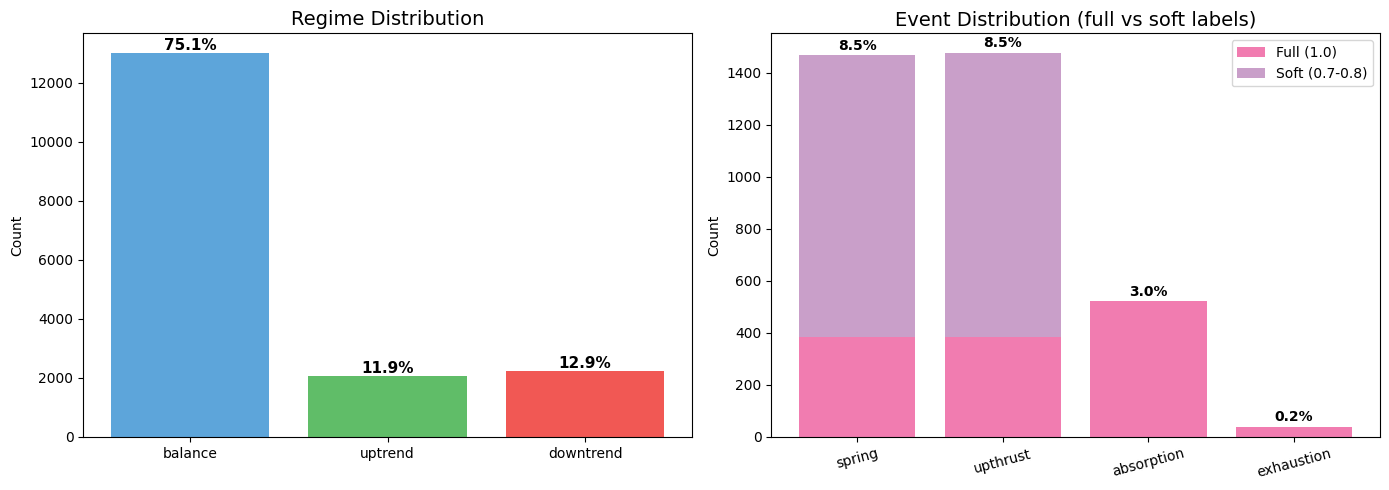


=== Regime ===
  balance     :  13016 (75.1%)
  uptrend     :   2068 (11.9%)
  downtrend   :   2239 (12.9%)

=== Events ===
  spring_like       :  1468 (8.47%)  [full=385, soft=1083]
  upthrust_like     :  1478 (8.53%)  [full=383, soft=1095]
  absorption_like   :   523 (3.02%)  [full=523, soft=0]
  exhaustion_like   :    40 (0.23%)  [full=40, soft=0]

=== Implied pos_weight (neg/pos ratio) ===
  spring_like       : 10.8x
  upthrust_like     : 10.7x
  absorption_like   : 32.1x
  exhaustion_like   : 432.1x


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regime distribution
regime_counts = np.bincount(regime, minlength=3)
regime_pcts = regime_counts / len(regime) * 100
colors_regime = ['#5DA5DA', '#60BD68', '#F15854']
bars_r = axes[0].bar(REGIME_NAMES, regime_counts, color=colors_regime)
for bar, pct in zip(bars_r, regime_pcts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{pct:.1f}%', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Regime Distribution', fontsize=14)
axes[0].set_ylabel('Count')

# Event distribution
event_full = [(events[:, j] >= 1.0).sum() for j in range(4)]
event_soft = [(events[:, j] > 0).sum() - (events[:, j] >= 1.0).sum() for j in range(4)]
event_total = [(events[:, j] > 0).sum() for j in range(4)]
x = np.arange(4)
axes[1].bar(x, event_full, label='Full (1.0)', color='#F17CB0')
axes[1].bar(x, event_soft, bottom=event_full, label='Soft (0.7-0.8)', color='#B276B2', alpha=0.7)
for i, (total, pct) in enumerate(zip(event_total, [t/len(events)*100 for t in event_total])):
    axes[1].text(i, total + 20, f'{pct:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels([n.replace('_like', '') for n in EVENT_NAMES], rotation=15)
axes[1].set_title('Event Distribution (full vs soft labels)', fontsize=14)
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

# Print table
print('\n=== Regime ===')
for i, name in enumerate(REGIME_NAMES):
    print(f'  {name:12s}: {regime_counts[i]:6d} ({regime_pcts[i]:.1f}%)')

print('\n=== Events ===')
for j, name in enumerate(EVENT_NAMES):
    total = event_total[j]
    full = event_full[j]
    soft = event_soft[j]
    print(f'  {name:18s}: {total:5d} ({total/len(events)*100:.2f}%)  [full={full}, soft={soft}]')

# Effective pos_weight for BCE
print('\n=== Implied pos_weight (neg/pos ratio) ===')
for j, name in enumerate(EVENT_NAMES):
    pos = max((events[:, j] > 0).sum(), 1)
    neg = len(events) - pos
    print(f'  {name:18s}: {neg/pos:.1f}x')


## 2. Train / Val Split Distribution

In [31]:
train_regime = regime[:TRAIN_END_BAR]
val_regime = regime[TRAIN_END_BAR:]
train_events = events[:TRAIN_END_BAR]
val_events = events[TRAIN_END_BAR:]

print('=== Regime by split ===')
for i, name in enumerate(REGIME_NAMES):
    tr = (train_regime == i).sum()
    va = (val_regime == i).sum()
    print(f'  {name:12s}: train={tr:5d} ({tr/len(train_regime)*100:.1f}%)  '
          f'val={va:5d} ({va/len(val_regime)*100:.1f}%)')

print('\n=== Events by split ===')
for j, name in enumerate(EVENT_NAMES):
    tr = (train_events[:, j] > 0).sum()
    va = (val_events[:, j] > 0).sum()
    print(f'  {name:18s}: train={tr:5d} ({tr/len(train_events)*100:.2f}%)  '
          f'val={va:5d} ({va/len(val_events)*100:.2f}%)')


=== Regime by split ===
  balance     : train=10555 (76.2%)  val= 2461 (71.0%)
  uptrend     : train= 1757 (12.7%)  val=  311 (9.0%)
  downtrend   : train= 1546 (11.2%)  val=  693 (20.0%)

=== Events by split ===
  spring_like       : train= 1122 (8.10%)  val=  346 (9.99%)
  upthrust_like     : train= 1179 (8.51%)  val=  299 (8.63%)
  absorption_like   : train=  416 (3.00%)  val=  107 (3.09%)
  exhaustion_like   : train=   32 (0.23%)  val=    8 (0.23%)


## 3. Temporal Distribution — Are Labels Clustered?

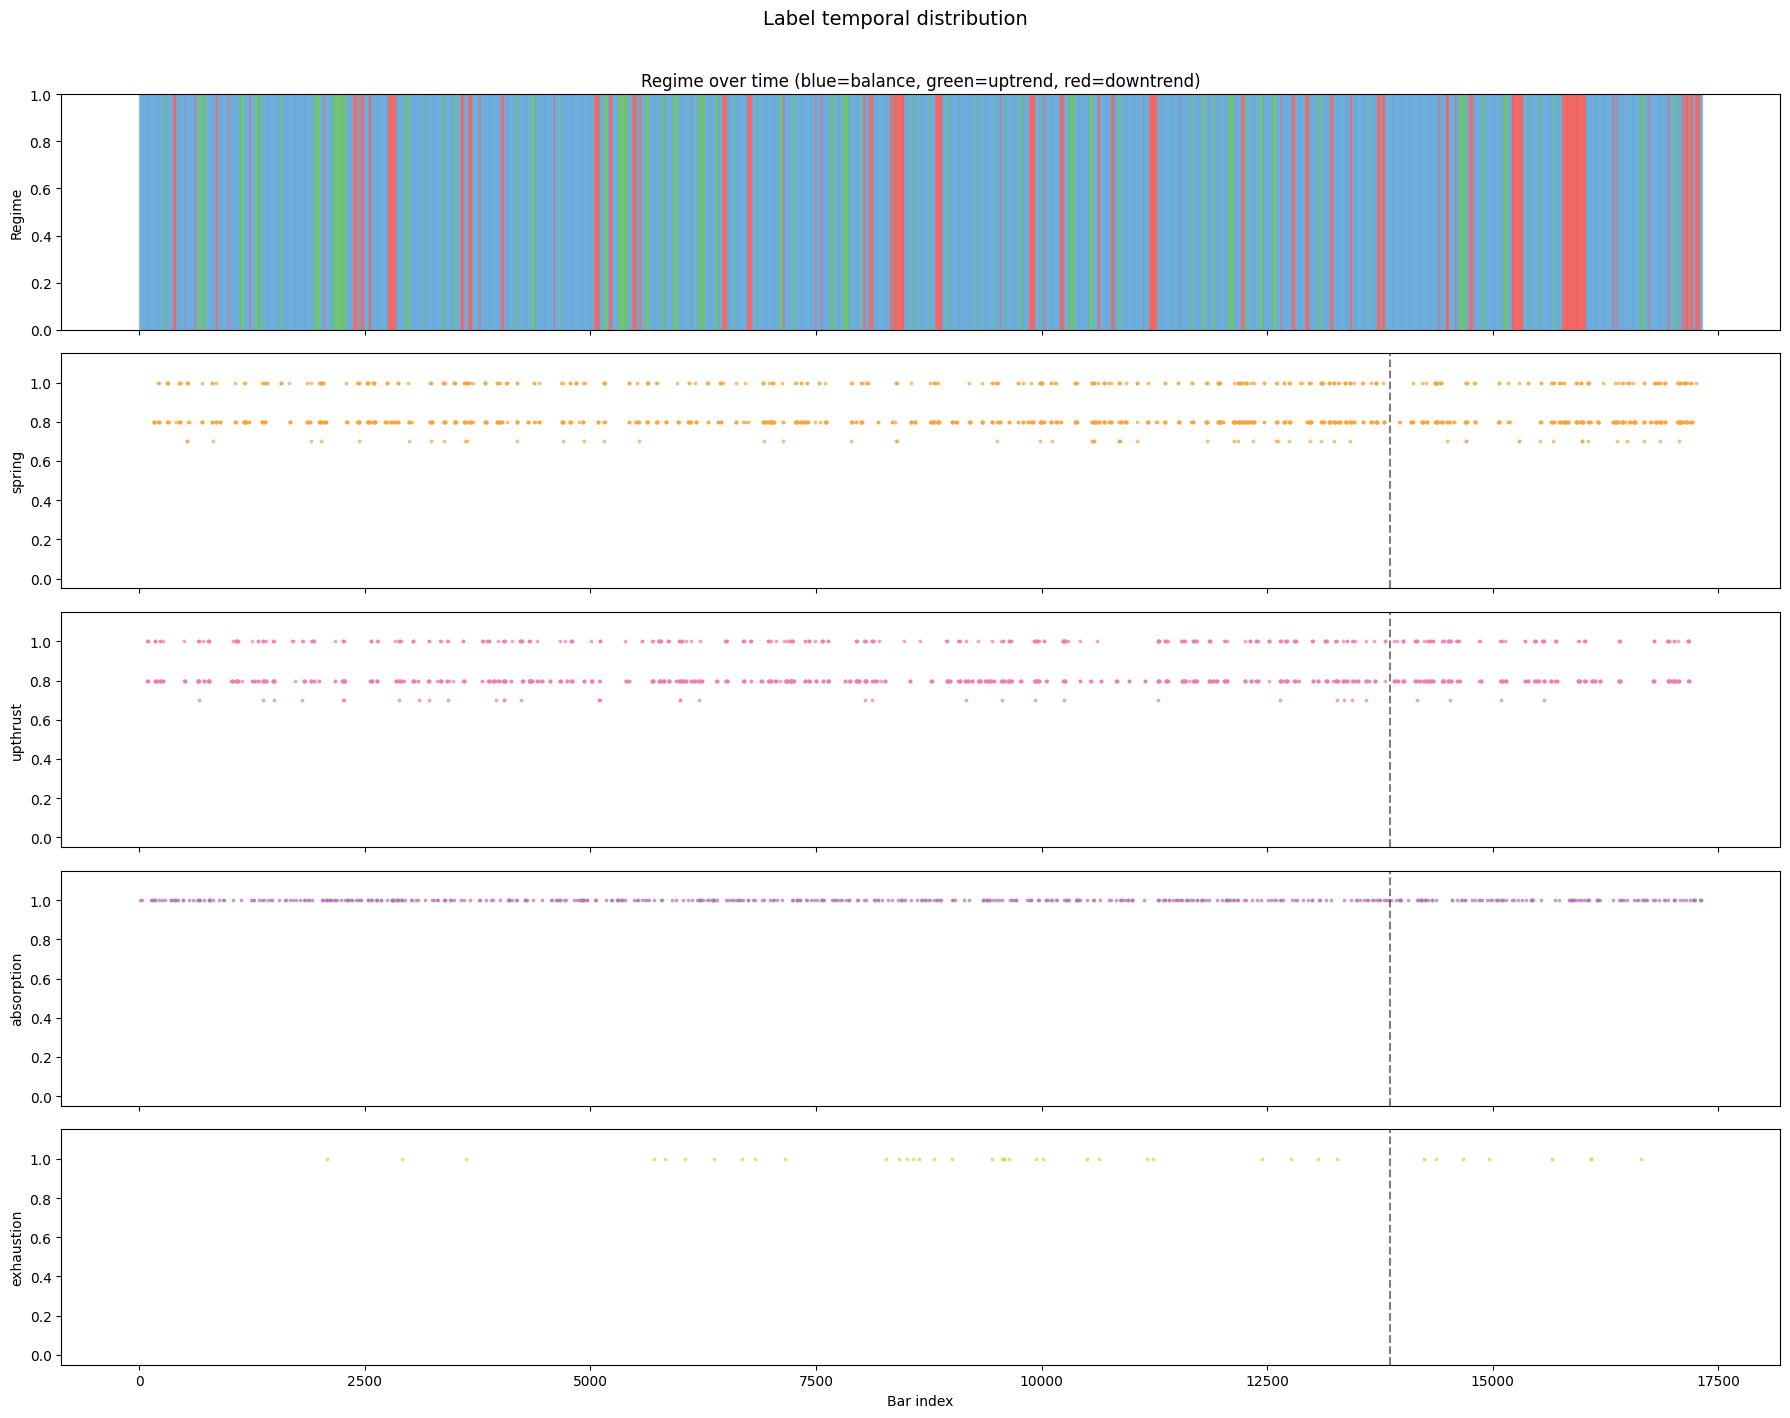

=== Inter-event gaps (bars between consecutive events) ===
  spring_like       : median_gap=1, mean=12, min=1, max=280, pct_gap<=1: 68.5%
  upthrust_like     : median_gap=1, mean=12, min=1, max=358, pct_gap<=1: 68.6%
  absorption_like   : median_gap=27, mean=33, min=1, max=177, pct_gap<=1: 4.8%
  exhaustion_like   : median_gap=286, mean=374, min=1, max=2091, pct_gap<=1: 5.1%


In [32]:
fig, axes = plt.subplots(5, 1, figsize=(18, 14), sharex=True)

# Regime over time (downsampled for speed)
step = 10
for i in range(0, len(regime) - step, step):
    axes[0].axvspan(i, i+step, color=['#5DA5DA','#60BD68','#F15854'][regime[i]], alpha=0.5)
axes[0].set_ylabel('Regime')
axes[0].set_title('Regime over time (blue=balance, green=uptrend, red=downtrend)')
axes[0].set_ylim(0, 1)

# Events over time
event_colors = ['#FAA43A', '#F17CB0', '#B276B2', '#DECF3F']
for j in range(4):
    active = np.where(events[:, j] > 0)[0]
    strengths = events[active, j]
    axes[j+1].scatter(active, strengths, s=3, alpha=0.6, color=event_colors[j])
    axes[j+1].set_ylabel(EVENT_NAMES[j].replace('_like', ''))
    axes[j+1].set_ylim(-0.05, 1.15)
    axes[j+1].axvline(TRAIN_END_BAR, color='black', ls='--', alpha=0.5, label='train/val split')

axes[-1].set_xlabel('Bar index')
plt.suptitle('Label temporal distribution', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Gap statistics
print('=== Inter-event gaps (bars between consecutive events) ===')
for j, name in enumerate(EVENT_NAMES):
    active = np.where(events[:, j] > 0)[0]
    if len(active) > 1:
        gaps = np.diff(active)
        print(f'  {name:18s}: median_gap={np.median(gaps):.0f}, '
              f'mean={np.mean(gaps):.0f}, min={gaps.min()}, max={gaps.max()}, '
              f'pct_gap<=1: {(gaps<=1).sum()/len(gaps)*100:.1f}%')
    else:
        print(f'  {name:18s}: too few events')


## 4. Event Overlap — Do Multiple Events Fire Together?

In [33]:
active_mask = events > 0  # (n, 4) bool
n_active_per_bar = active_mask.sum(axis=1)

print('=== Events-per-bar distribution ===')
for k in range(5):
    cnt = (n_active_per_bar == k).sum()
    print(f'  {k} events: {cnt:6d} bars ({cnt/len(events)*100:.2f}%)')

# Co-occurrence matrix
print('\n=== Co-occurrence matrix (bars where BOTH events fire) ===')
cooc = np.zeros((4, 4), dtype=int)
for j in range(4):
    for k in range(4):
        cooc[j, k] = ((events[:, j] > 0) & (events[:, k] > 0)).sum()

header = '                   ' + '  '.join(f'{n[:8]:>8s}' for n in EVENT_NAMES)
print(header)
for j, name in enumerate(EVENT_NAMES):
    row = '  '.join(f'{cooc[j,k]:8d}' for k in range(4))
    print(f'  {name:18s}{row}')

# Spring + upthrust overlap (should be ~0)
both_su = ((events[:, 0] > 0) & (events[:, 1] > 0)).sum()
print(f'\n  spring + upthrust overlap: {both_su} bars')
if both_su > 0:
    print('  WARNING: Spring and upthrust should NOT fire on the same bar!')


=== Events-per-bar distribution ===
  0 events:  13912 bars (80.31%)
  1 events:   3313 bars (19.12%)
  2 events:     98 bars (0.57%)
  3 events:      0 bars (0.00%)
  4 events:      0 bars (0.00%)

=== Co-occurrence matrix (bars where BOTH events fire) ===
                   spring_l  upthrust  absorpti  exhausti
  spring_like           1468         8        46         2
  upthrust_like            8      1478        38         4
  absorption_like         46        38       523         0
  exhaustion_like          2         4         0        40

  spring + upthrust overlap: 8 bars


## 5. Visual Spot-Checks — Do Labels Match Price Action?

In [34]:
def plot_event_examples(event_idx, event_name, n_examples=8, context=40):
    """Plot price action around labeled events for visual verification."""
    active = np.where(events[:, event_idx] >= 1.0)[0]  # full strength only
    if len(active) == 0:
        active = np.where(events[:, event_idx] > 0)[0]
        if len(active) == 0:
            print(f'No {event_name} events found')
            return
        print(f'No full-strength events; showing soft labels')

    # Sample spread across the dataset
    step = max(1, len(active) // n_examples)
    sample_idx = active[::step][:n_examples]

    n_cols = min(4, len(sample_idx))
    n_rows = (len(sample_idx) + n_cols - 1) // n_cols
    fig, axes_grid = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    if n_rows == 1 and n_cols == 1:
        axes_grid = np.array([axes_grid])
    axes_flat = np.array(axes_grid).flatten()

    for ax_i, bar_i in enumerate(sample_idx):
        ax = axes_flat[ax_i]
        start = max(0, bar_i - context)
        end = min(len(bars), bar_i + context // 2)
        window = bars.iloc[start:end]

        x = np.arange(len(window))
        for xi, (_, row) in enumerate(window.iterrows()):
            color = '#60BD68' if row['close'] >= row['open'] else '#F15854'
            ax.plot([xi, xi], [row['low'], row['high']], color='gray', lw=0.5)
            ax.plot([xi, xi], [row['open'], row['close']], color=color, lw=2.5)

        event_x = bar_i - start
        ax.axvline(event_x, color='blue', ls='--', alpha=0.7, lw=1.5)
        ax.set_title(f'{event_name} @ bar {bar_i}\nscore={events[bar_i, event_idx]:.1f}', fontsize=10)

        ax2 = ax.twinx()
        vol_window = window['volume'].values
        ax2.bar(x, vol_window, alpha=0.15, color='gray', width=0.8)
        ax2.set_ylim(0, vol_window.max() * 3)
        ax2.set_yticks([])
        ax.set_xlim(-1, len(window))

    for ax_i in range(len(sample_idx), len(axes_flat)):
        axes_flat[ax_i].set_visible(False)

    plt.suptitle(f'{event_name.upper()} Examples (blue line = event bar)', fontsize=14)
    plt.tight_layout()
    plt.show()


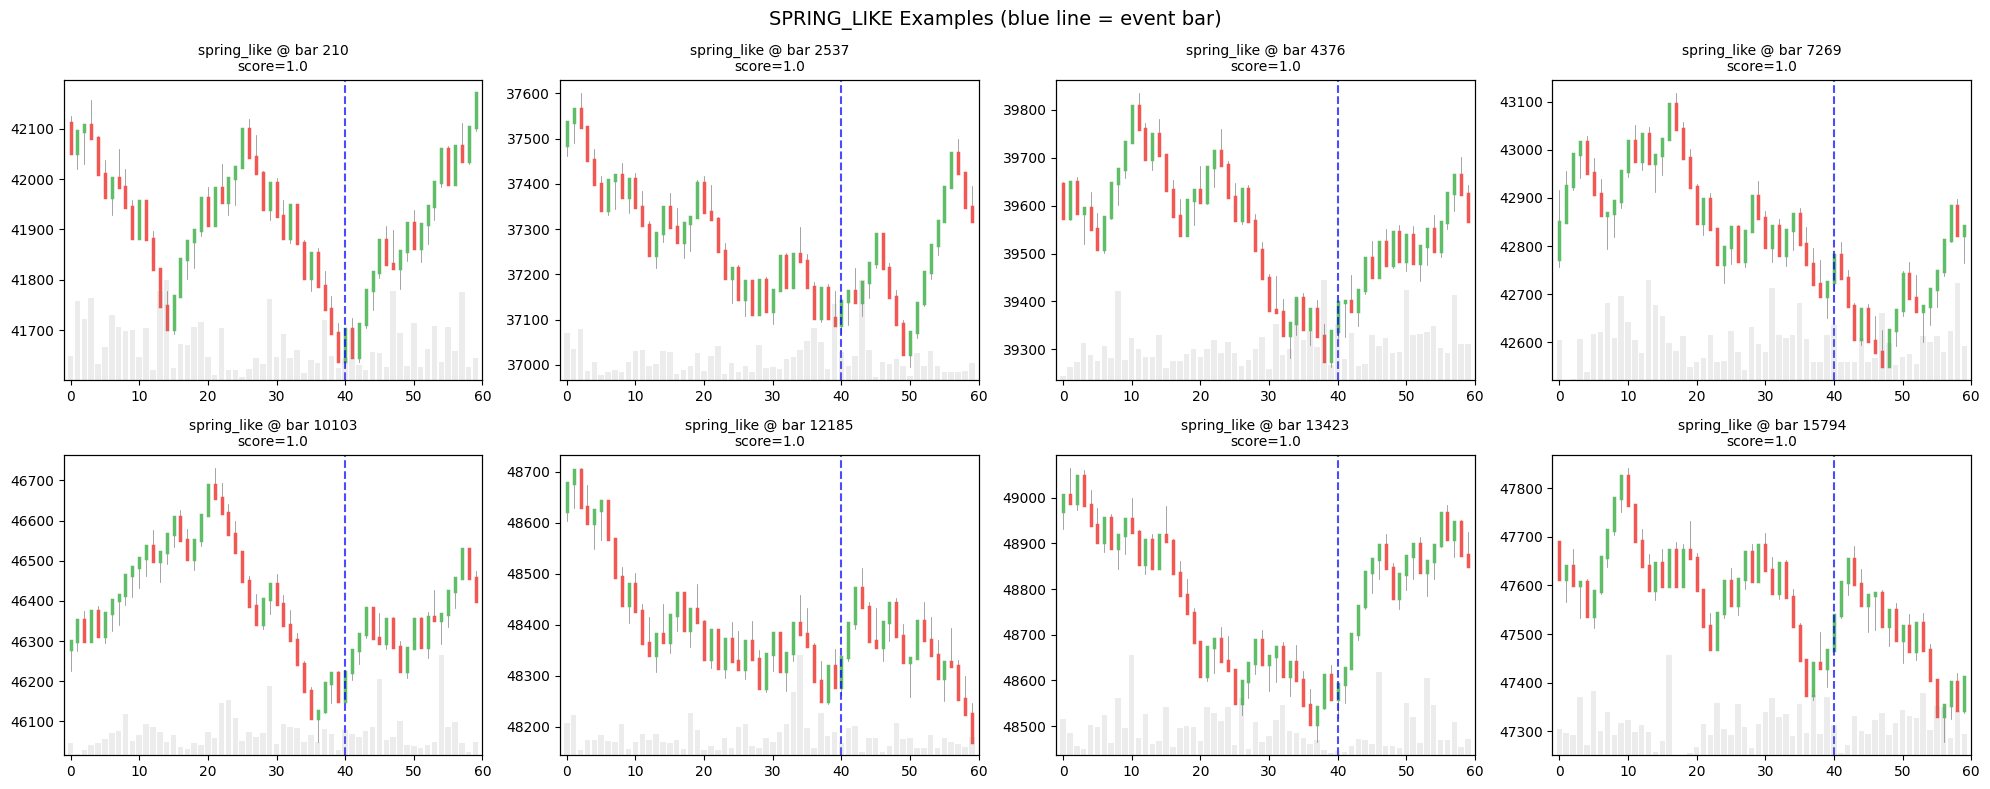

In [35]:
plot_event_examples(0, 'spring_like')

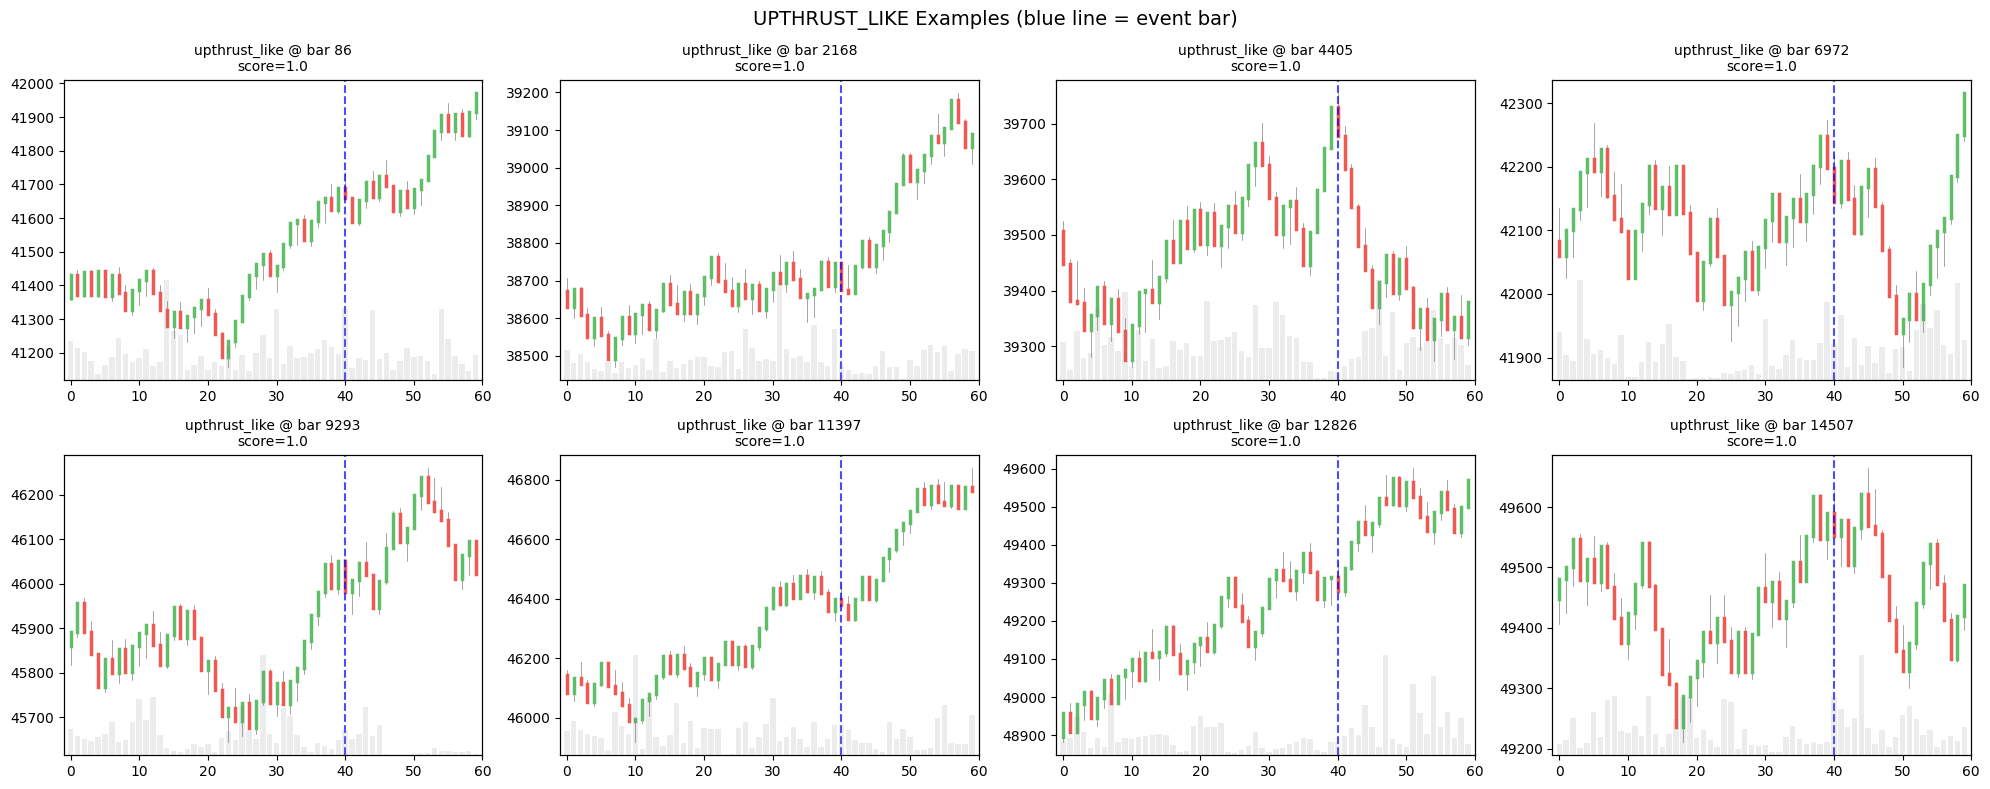

In [36]:
plot_event_examples(1, 'upthrust_like')

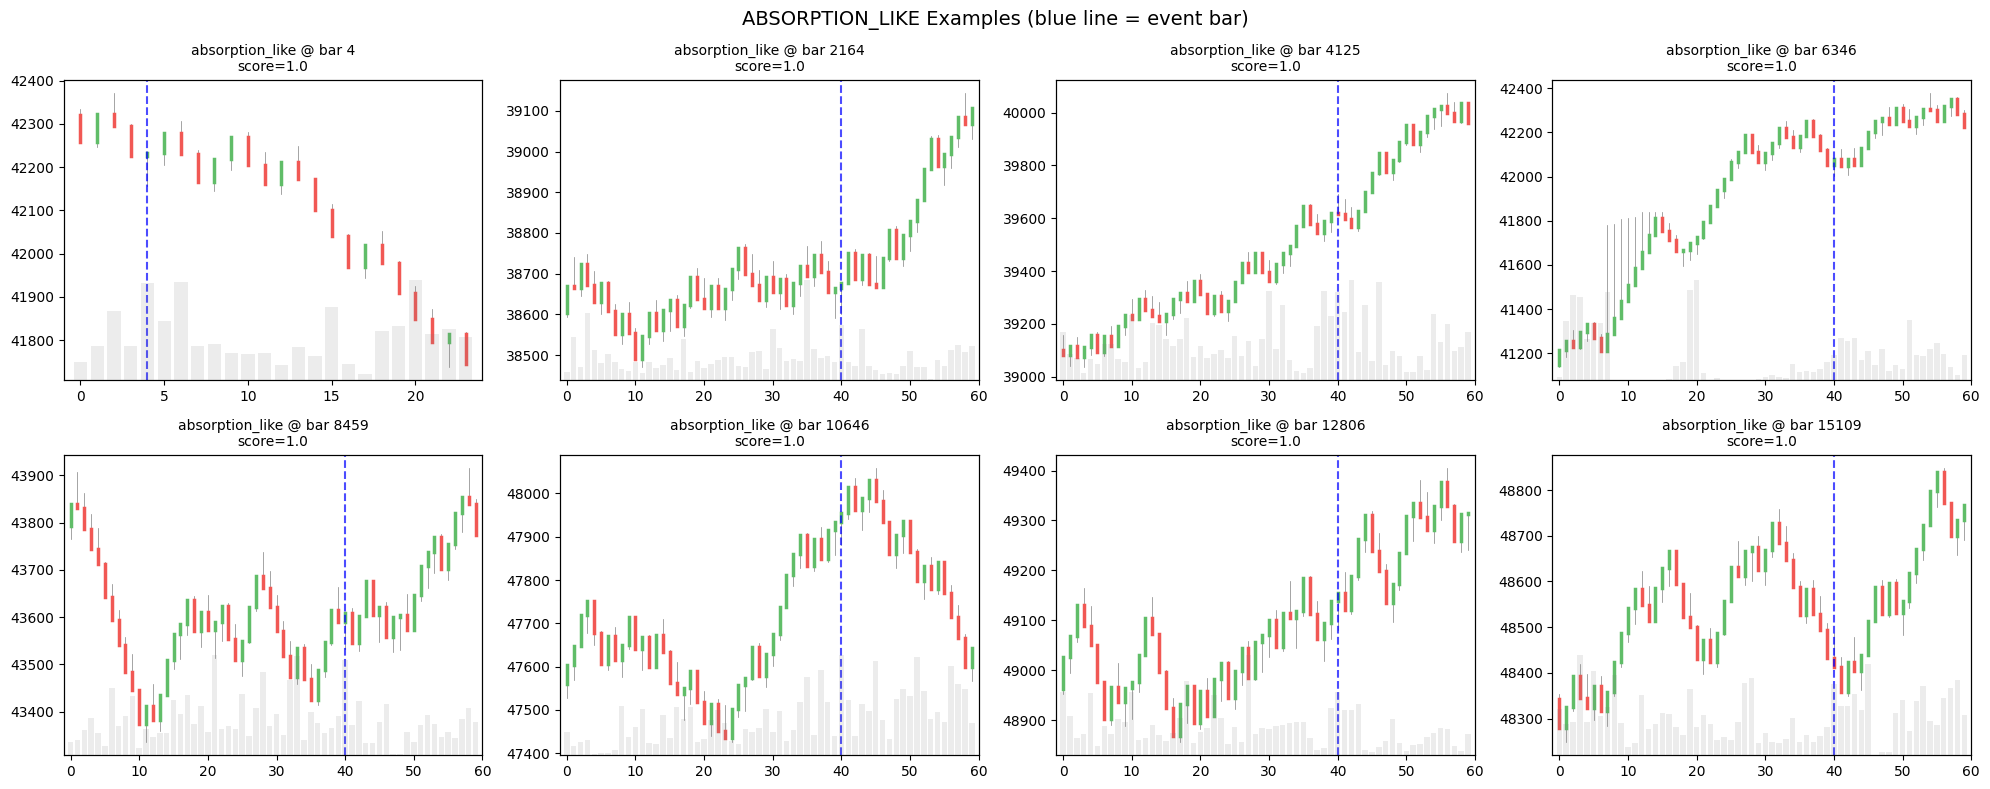

In [37]:
plot_event_examples(2, 'absorption_like')

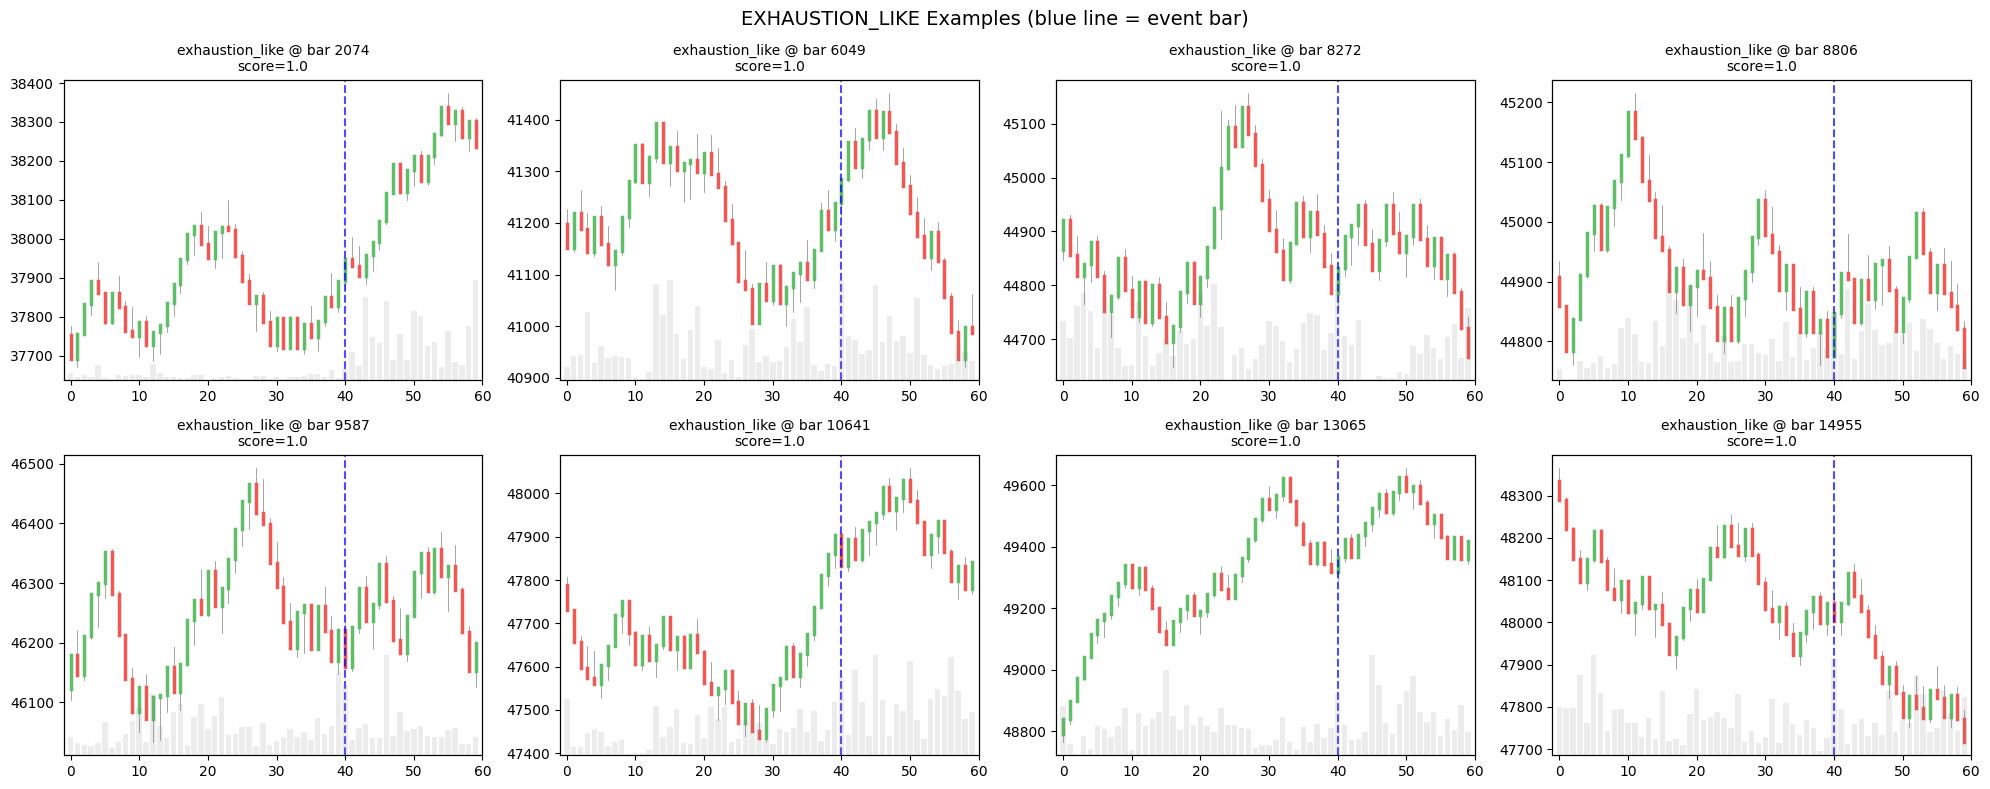

In [38]:
plot_event_examples(3, 'exhaustion_like')

## 6. Feature Leakage Check

Are the 29 transformer input features correlated with the heuristic scores we excluded?
High correlation means the model can still "see" the heuristics indirectly.


=== Top Feature-Heuristic Correlations (|r| > 0.3) ===
  body_ratio                   <-> upthrust_score        : r=+0.302
  body_ratio                   <-> bc_score              : r=+0.304
  upper_wick_ratio             <-> sc_score              : r=+0.410
  lower_wick_ratio             <-> spring_score          : r=+0.323
  lower_wick_ratio             <-> bc_score              : r=+0.389
  close_location               <-> sc_score              : r=-0.373
  close_location               <-> bc_score              : r=+0.371
  vol_vs_ma20                  <-> sc_score              : r=+0.607
  vol_vs_ma20                  <-> bc_score              : r=+0.615
  vol_vs_ma20                  <-> absorption_score      : r=+0.729
  vol_vs_ma20                  <-> stopping_action_score : r=+0.317
  duration_norm                <-> sc_score              : r=+0.355
  duration_norm                <-> bc_score              : r=+0.351
  duration_norm                <-> absorption_score      : r=

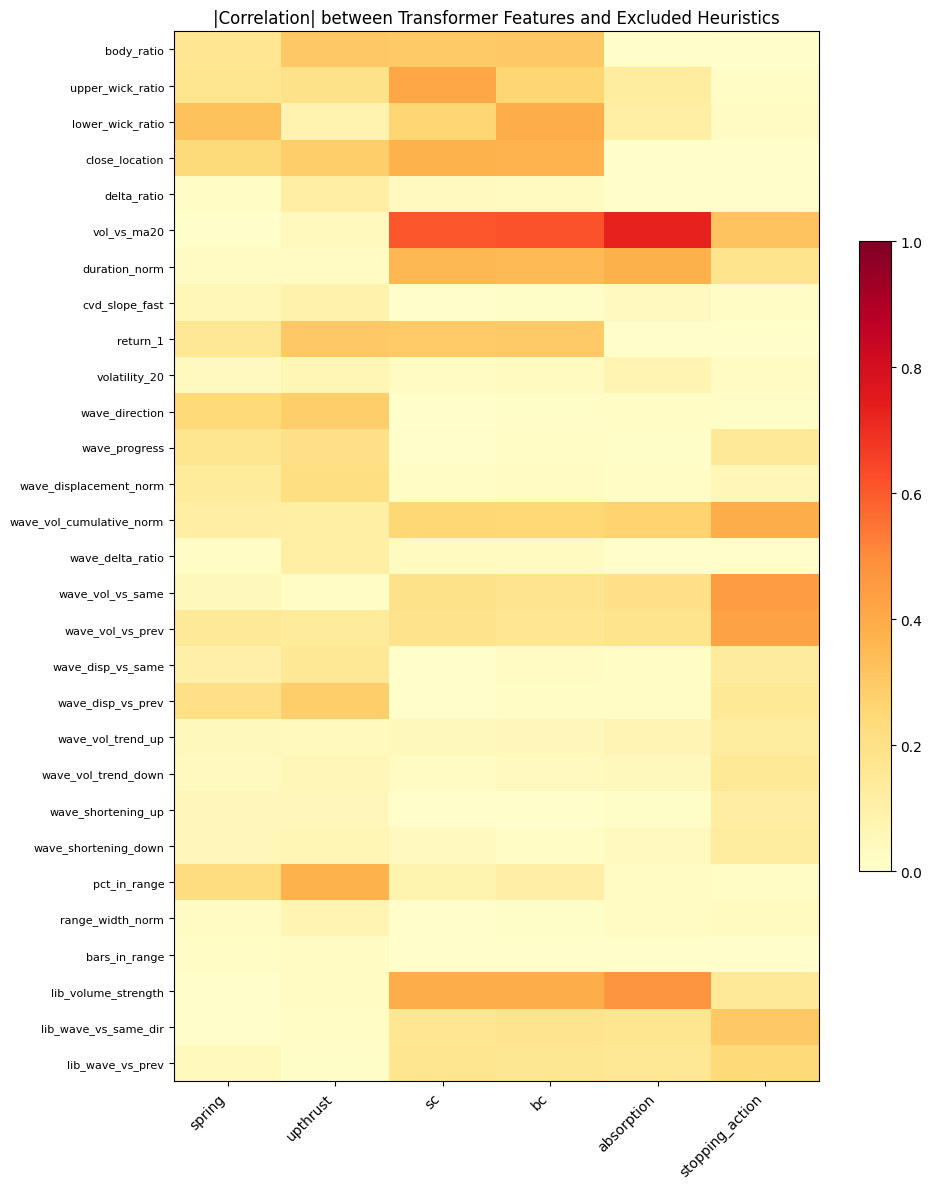

In [39]:
from wyckoff_rl.transformer.config import TRANSFORMER_FEATURE_INDICES

# Heuristic score columns that we EXCLUDED
heuristic_indices = [35, 36, 37, 38, 39, 41]
heuristic_names = [feature_names[i] for i in heuristic_indices]

# Compute correlations
included_feats = tech_ary[:, TRANSFORMER_FEATURE_INDICES]
excluded_feats = tech_ary[:, heuristic_indices]

corr_matrix = np.corrcoef(included_feats.T, excluded_feats.T)
n_inc = len(TRANSFORMER_FEATURE_INDICES)
n_exc = len(heuristic_indices)
cross_corr = corr_matrix[:n_inc, n_inc:]

# Find high correlations
print('=== Top Feature-Heuristic Correlations (|r| > 0.3) ===')
high_corr_found = False
for i in range(n_inc):
    for j in range(n_exc):
        r = cross_corr[i, j]
        if abs(r) > 0.3:
            inc_name = feature_names[TRANSFORMER_FEATURE_INDICES[i]]
            exc_name = heuristic_names[j]
            print(f'  {inc_name:28s} <-> {exc_name:22s}: r={r:+.3f}')
            high_corr_found = True

if not high_corr_found:
    print('  None found -- transformer inputs are clean of heuristic leakage')

# Heatmap
fig, ax = plt.subplots(figsize=(10, 12))
im = ax.imshow(np.abs(cross_corr), cmap='YlOrRd', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(n_exc))
ax.set_xticklabels([n.replace('_score', '') for n in heuristic_names], rotation=45, ha='right')
ax.set_yticks(range(n_inc))
ax.set_yticklabels([feature_names[idx] for idx in TRANSFORMER_FEATURE_INDICES], fontsize=8)
ax.set_title('|Correlation| between Transformer Features and Excluded Heuristics', fontsize=12)
plt.colorbar(im, ax=ax, shrink=0.6)
plt.tight_layout()
plt.show()


## 7. Label vs Forward Returns — Is There Alpha?

The most important test: do labeled events actually predict profitable direction?


In [40]:
close = bars['close'].values

# Forward returns at various horizons
horizons = [5, 10, 20, 50]
fwd_returns = {}
for h in horizons:
    fr = np.full(len(close), np.nan)
    fr[:-h] = (close[h:] - close[:-h]) / close[:-h] * 100  # percent
    fwd_returns[h] = fr

print('=== Forward Returns by Event (mean % return after event) ===')
print(f'{"":18s}', '  '.join(f'{h:>6d}-bar' for h in horizons))
print('-' * 70)

for j, name in enumerate(EVENT_NAMES):
    mask = events[:, j] >= 1.0  # full strength
    if mask.sum() == 0:
        continue
    row = []
    for h in horizons:
        ret = fwd_returns[h][mask]
        ret = ret[~np.isnan(ret)]
        row.append(f'{np.mean(ret):+7.3f}' if len(ret) > 0 else '    N/A')
    print(f'  {name:18s}', '  '.join(row))

# Baseline: all bars
row_all = []
for h in horizons:
    ret = fwd_returns[h][~np.isnan(fwd_returns[h])]
    row_all.append(f'{np.mean(ret):+7.3f}')
print(f'  {"ALL BARS":18s}', '  '.join(row_all))

# Directional accuracy
print('\n=== Directional accuracy (% correct direction, 10-bar horizon) ===')
for j, (name, expected_dir) in enumerate([
    ('spring_like', 'up'),
    ('upthrust_like', 'down'),
    ('absorption_like', 'N/A'),
    ('exhaustion_like', 'N/A'),
]):
    mask = events[:, j] >= 1.0
    ret = fwd_returns[10][mask]
    ret = ret[~np.isnan(ret)]
    if len(ret) == 0:
        continue
    if expected_dir == 'up':
        acc = (ret > 0).sum() / len(ret) * 100
        print(f'  {name:18s}: {acc:.1f}% up (n={len(ret)})  '
              f'[>50% = edge, >60% = strong]')
    elif expected_dir == 'down':
        acc = (ret < 0).sum() / len(ret) * 100
        print(f'  {name:18s}: {acc:.1f}% down (n={len(ret)})  '
              f'[>50% = edge, >60% = strong]')
    else:
        up_pct = (ret > 0).sum() / len(ret) * 100
        print(f'  {name:18s}: {up_pct:.1f}% up / {100-up_pct:.1f}% down (n={len(ret)})')


=== Forward Returns by Event (mean % return after event) ===
                        5-bar      10-bar      20-bar      50-bar
----------------------------------------------------------------------
  spring_like         +0.000   +0.009   -0.034   -0.001
  upthrust_like       +0.006   +0.018   +0.037   +0.058
  absorption_like     +0.018   +0.008   +0.042   +0.118
  exhaustion_like     +0.021   +0.035   +0.019   +0.077
  ALL BARS            +0.002   +0.005   +0.010   +0.029

=== Directional accuracy (% correct direction, 10-bar horizon) ===
  spring_like       : 50.1% up (n=385)  [>50% = edge, >60% = strong]
  upthrust_like     : 46.0% down (n=383)  [>50% = edge, >60% = strong]
  absorption_like   : 49.8% up / 50.2% down (n=522)
  exhaustion_like   : 55.0% up / 45.0% down (n=40)


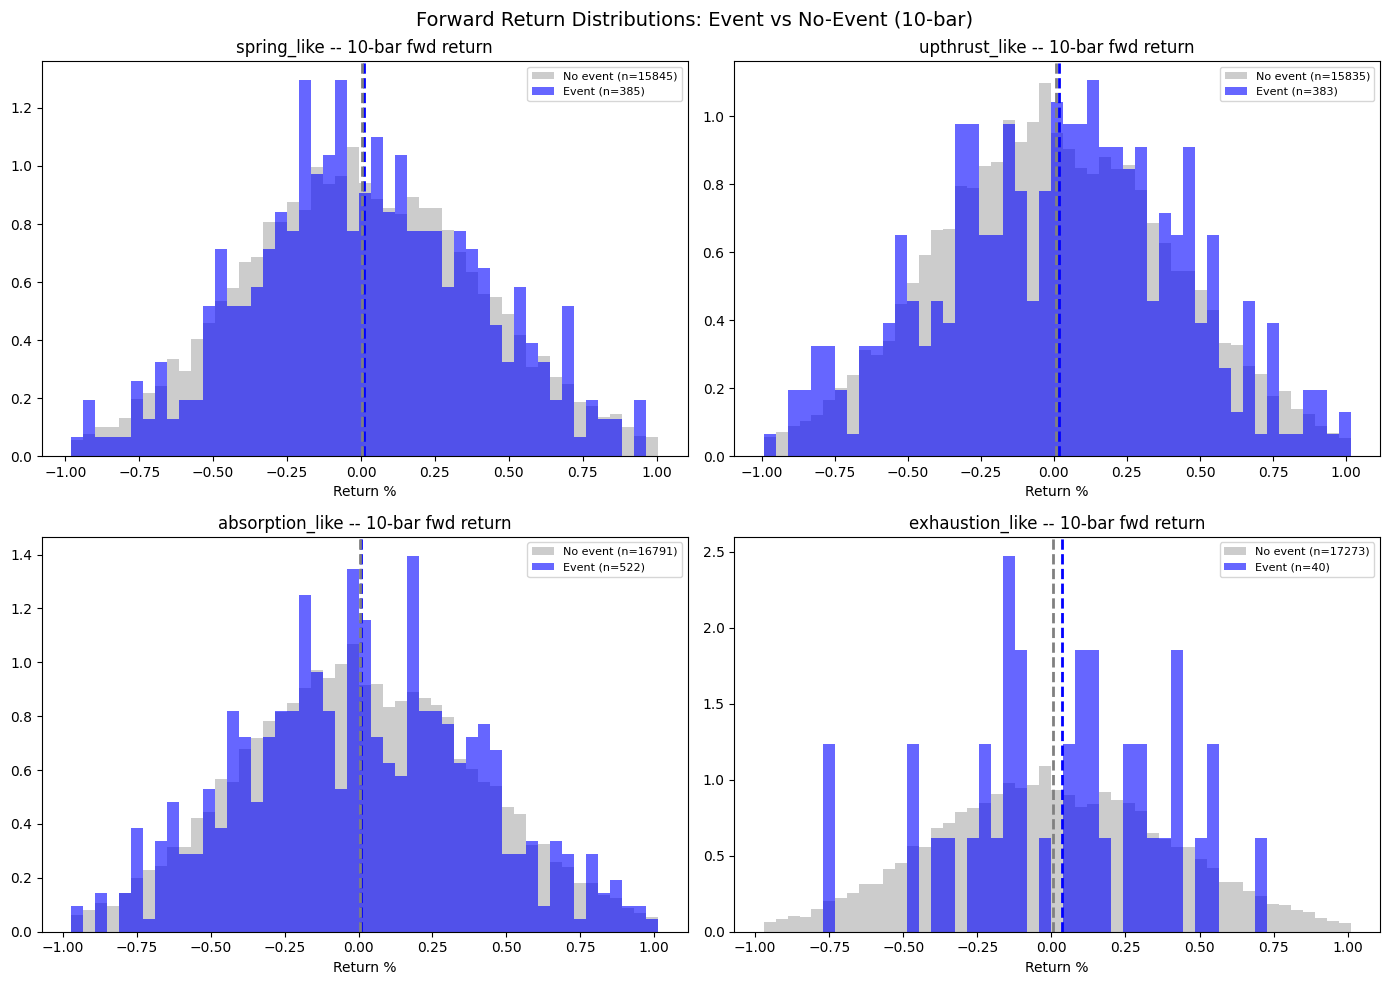

In [41]:
# Distribution of forward returns by event vs no-event
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

horizon = 10
fr = fwd_returns[horizon]

for j, (name, ax) in enumerate(zip(EVENT_NAMES, axes)):
    mask_event = events[:, j] >= 1.0
    mask_none = events[:, j] == 0

    ret_event = fr[mask_event & ~np.isnan(fr)]
    ret_none = fr[mask_none & ~np.isnan(fr)]

    if len(ret_event) < 5:
        ax.text(0.5, 0.5, f'{name}\nToo few events', transform=ax.transAxes, ha='center')
        continue

    pct_low = min(np.percentile(ret_none, 1), np.percentile(ret_event, 1))
    pct_high = max(np.percentile(ret_none, 99), np.percentile(ret_event, 99))
    bins = np.linspace(pct_low, pct_high, 50)
    ax.hist(ret_none, bins=bins, alpha=0.4, density=True, label=f'No event (n={len(ret_none)})', color='gray')
    ax.hist(ret_event, bins=bins, alpha=0.6, density=True, label=f'Event (n={len(ret_event)})', color='blue')
    ax.axvline(np.mean(ret_event), color='blue', ls='--', lw=2)
    ax.axvline(np.mean(ret_none), color='gray', ls='--', lw=2)
    ax.set_title(f'{name} -- {horizon}-bar fwd return', fontsize=12)
    ax.legend(fontsize=8)
    ax.set_xlabel('Return %')

plt.suptitle(f'Forward Return Distributions: Event vs No-Event ({horizon}-bar)', fontsize=14)
plt.tight_layout()
plt.show()


## 8. Regime Transitions — Realistic or Noisy?

Total regime segments: 310
Avg transitions per 100 bars: 1.79
  balance     : median=66, mean=84, min=4, max=373, n_segments=155
  uptrend     : median=17, mean=27, min=3, max=136, n_segments=77
  downtrend   : median=18, mean=29, min=1, max=134, n_segments=78


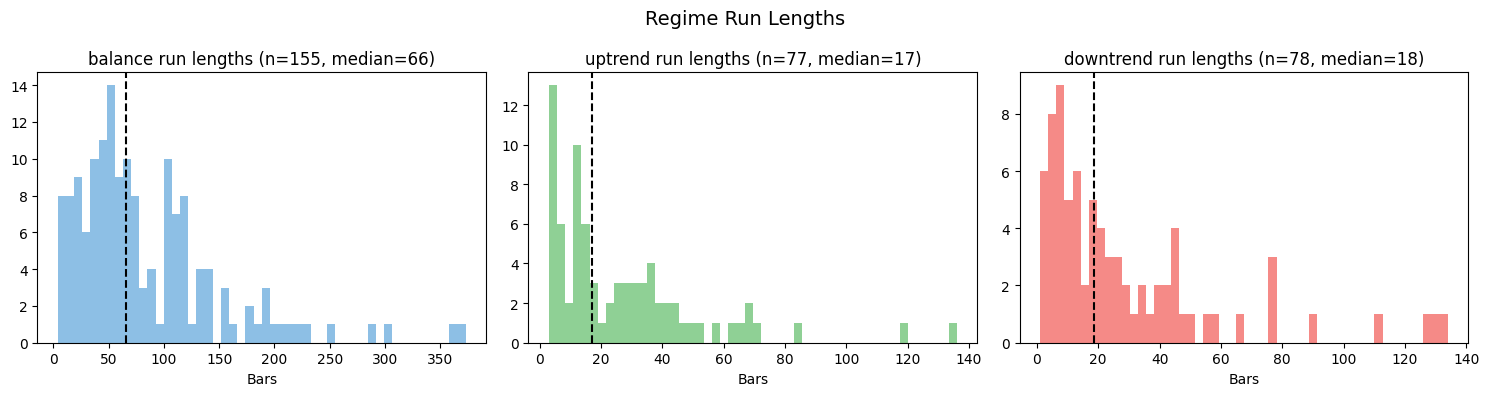


=== Regime Transition Matrix ===
   From / To   balance   uptrend   downtrend
  balance              0        77        78
  uptrend             77         0         0
  downtrend           77         0         0

Short segments (<=2 bars): 1 (0.3% of all segments)


In [42]:
# Regime run-length analysis
runs = []
current_regime = regime[0]
current_len = 1
for i in range(1, len(regime)):
    if regime[i] == current_regime:
        current_len += 1
    else:
        runs.append((current_regime, current_len))
        current_regime = regime[i]
        current_len = 1
runs.append((current_regime, current_len))

print(f'Total regime segments: {len(runs)}')
print(f'Avg transitions per 100 bars: {len(runs) / len(regime) * 100:.2f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors_regime = ['#5DA5DA', '#60BD68', '#F15854']
for r_idx, (r_name, color) in enumerate(zip(REGIME_NAMES, colors_regime)):
    lens = [rl for rr, rl in runs if rr == r_idx]
    if lens:
        axes[r_idx].hist(lens, bins=50, color=color, alpha=0.7)
        axes[r_idx].set_title(f'{r_name} run lengths (n={len(lens)}, median={np.median(lens):.0f})')
        axes[r_idx].set_xlabel('Bars')
        axes[r_idx].axvline(np.median(lens), color='black', ls='--')
        print(f'  {r_name:12s}: median={np.median(lens):.0f}, mean={np.mean(lens):.0f}, '
              f'min={min(lens)}, max={max(lens)}, n_segments={len(lens)}')

plt.suptitle('Regime Run Lengths', fontsize=14)
plt.tight_layout()
plt.show()

# Transition matrix
trans = np.zeros((3, 3), dtype=int)
for i in range(1, len(regime)):
    if regime[i] != regime[i-1]:
        trans[regime[i-1], regime[i]] += 1

print('\n=== Regime Transition Matrix ===')
print(f'{"From / To":>12s}  {"balance":>8s}  {"uptrend":>8s}  {"downtrend":>10s}')
for i, name in enumerate(REGIME_NAMES):
    row = '  '.join(f'{trans[i,j]:8d}' for j in range(3))
    print(f'  {name:12s}  {row}')

# Bad sign: lots of 1-bar regime segments
short_runs = sum(1 for _, rl in runs if rl <= 2)
print(f'\nShort segments (<=2 bars): {short_runs} ({short_runs/len(runs)*100:.1f}% of all segments)')
if short_runs / len(runs) > 0.2:
    print('  -> Labels are NOISY -- too many rapid regime flips')


## 9. Pretrained Model Evaluation

In [43]:
import torch
import glob

# Find best pretrained checkpoint
ckpt_path = f'{PRETRAIN_DIR}/pretrained_best.pt'
if not Path(ckpt_path).exists():
    ckpts = sorted(glob.glob(f'{PRETRAIN_DIR}/pretrained_*.pt'))
    ckpt_path = ckpts[-1] if ckpts else None

if ckpt_path:
    print(f'Loading checkpoint: {ckpt_path}')
    ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    print(f'Keys: {list(ckpt.keys())}')
    config = ckpt['config']
    print(f'Config: d_model={config.d_model}, n_layers={config.n_layers}, '
          f'd_ff={config.d_ff}, seq_len={config.seq_len}')
    print(f'Best epoch: {ckpt.get("epoch", "?")}, val_loss: {ckpt.get("val_loss", "?"):.4f}, '
          f'phase_acc: {ckpt.get("phase_acc", "?"):.4f}')
else:
    print('No pretrained checkpoint found')
    ckpt = None


Loading checkpoint: /opt/ElegantRL/checkpoints/transformer_us30_75pt/pretrained_best.pt
Keys: ['encoder', 'phase_head', 'event_head', 'config', 'epoch', 'val_loss', 'phase_acc', 'feat_mean', 'feat_std']
Config: d_model=32, n_layers=2, d_ff=96, seq_len=64
Best epoch: 44, val_loss: 1.2084, phase_acc: 0.5766


In [44]:
if ckpt is not None:
    from wyckoff_rl.transformer.train import WyckoffSequenceDataset
    from wyckoff_rl.transformer.actor import WyckoffTransformerEncoder
    from wyckoff_rl.transformer.heads import PhaseHead, EventHead
    from sklearn.metrics import (
        confusion_matrix, classification_report,
        precision_recall_curve, average_precision_score,
        ConfusionMatrixDisplay
    )

    # Build model
    encoder = WyckoffTransformerEncoder(config)
    phase_head = PhaseHead(config)
    event_head = EventHead(config)

    # Load weights
    encoder.load_state_dict(ckpt['encoder'])
    phase_head.load_state_dict(ckpt['phase_head'])
    event_head.load_state_dict(ckpt['event_head'])

    encoder.eval()
    phase_head.eval()
    event_head.eval()

    # Build val dataset — load all data, use checkpoint normalization stats,
    # restrict to val portion via Subset
    val_ds = WyckoffSequenceDataset(
        NPZ_PATH, LABEL_PATH, config,
        augment=False, end_idx=0  # load all data
    )
    # Use training normalization stats from checkpoint
    val_ds.feat_mean = ckpt['feat_mean']
    val_ds.feat_std = ckpt['feat_std']
    # Val portion: samples where the target bar >= TRAIN_END_BAR
    val_start_sample = max(0, TRAIN_END_BAR - val_ds.seq_len)
    val_indices = list(range(val_start_sample, len(val_ds)))
    val_subset = torch.utils.data.Subset(val_ds, val_indices)
    val_loader = torch.utils.data.DataLoader(val_subset, batch_size=256, shuffle=False)

    # Run inference
    all_regime_pred = []
    all_regime_true = []
    all_event_logits = []
    all_event_true = []

    with torch.no_grad():
        for batch in val_loader:
            feats = batch['features']
            latent = encoder(feats)
            last_latent = latent[:, -1, :]

            regime_logits = phase_head(last_latent)
            event_logits = event_head(last_latent)

            all_regime_pred.append(regime_logits.argmax(dim=1).numpy())
            all_regime_true.append(batch['phase'].numpy())
            all_event_logits.append(event_logits.numpy())
            all_event_true.append(batch['events'].numpy())

    regime_pred = np.concatenate(all_regime_pred)
    regime_true = np.concatenate(all_regime_true)
    event_logits_all = np.concatenate(all_event_logits)
    event_true_all = np.concatenate(all_event_true)
    event_probs = 1.0 / (1.0 + np.exp(-event_logits_all))  # sigmoid

    print(f'Val samples: {len(regime_pred)}')
    print(f'Regime accuracy: {(regime_pred == regime_true).mean()*100:.1f}%')
else:
    print('Skipping -- no checkpoint')


Val samples: 3465
Regime accuracy: 49.9%


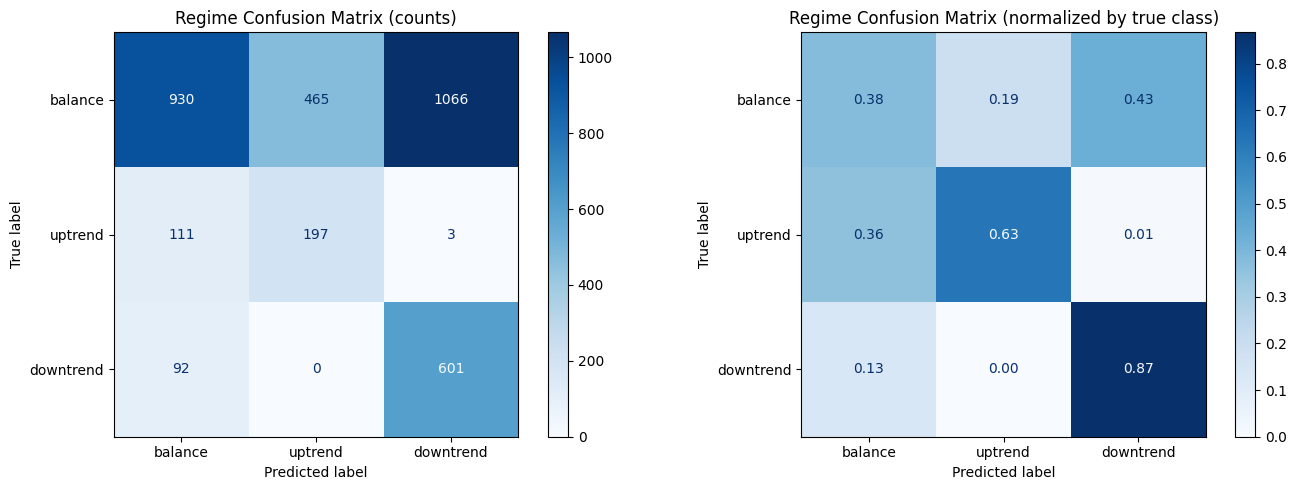


=== Regime Classification Report ===
              precision    recall  f1-score   support

     balance      0.821     0.378     0.518      2461
     uptrend      0.298     0.633     0.405       311
   downtrend      0.360     0.867     0.509       693

    accuracy                          0.499      3465
   macro avg      0.493     0.626     0.477      3465
weighted avg      0.682     0.499     0.506      3465



In [45]:
if ckpt is not None:
    # === Regime Confusion Matrix ===
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    cm = confusion_matrix(regime_true, regime_pred, labels=[0,1,2])
    disp = ConfusionMatrixDisplay(cm, display_labels=REGIME_NAMES)
    disp.plot(ax=axes[0], cmap='Blues', values_format='d')
    axes[0].set_title('Regime Confusion Matrix (counts)')

    cm_norm = confusion_matrix(regime_true, regime_pred, labels=[0,1,2], normalize='true')
    disp_norm = ConfusionMatrixDisplay(cm_norm, display_labels=REGIME_NAMES)
    disp_norm.plot(ax=axes[1], cmap='Blues', values_format='.2f')
    axes[1].set_title('Regime Confusion Matrix (normalized by true class)')

    plt.tight_layout()
    plt.show()

    print('\n=== Regime Classification Report ===')
    print(classification_report(regime_true, regime_pred,
                                target_names=REGIME_NAMES, digits=3))
else:
    print('Skipping -- no checkpoint')


In [49]:
# Verify we're using the L4 checkpoint
print(f"Encoder d_model: {config.d_model}, n_layers: {config.n_layers}, d_ff: {config.d_ff}, seq_len: {config.seq_len}")
print(f"Epoch: {ckpt.get('epoch')}, val_loss: {ckpt.get('val_loss'):.4f}, phase_acc: {ckpt.get('phase_acc'):.4f}")
print(f"Encoder param count: {sum(p.numel() for p in encoder.parameters()):,}")
print(f"Val dataset seq_len used: {full_ds.seq_len}")
print(f"Val samples: {len(regime_pred)}, unique preds: {np.unique(regime_pred, return_counts=True)}")

Encoder d_model: 32, n_layers: 2, d_ff: 96, seq_len: 64
Epoch: 44, val_loss: 1.2084, phase_acc: 0.5766
Encoder param count: 24,384
Val dataset seq_len used: 64
Val samples: 3465, unique preds: (array([0, 1, 2]), array([1133,  662, 1670]))


=== Event PR-AUC (Precision-Recall Area Under Curve) ===
  spring_like       : AP=0.3230, baseline=0.0999, lift=3.2x, pos=346, neg=3119
  upthrust_like     : AP=0.3120, baseline=0.0863, lift=3.6x, pos=299, neg=3166
  absorption_like   : AP=0.0304, baseline=0.0309, lift=1.0x, pos=107, neg=3358
  exhaustion_like   : AP=0.0095, baseline=0.0023, lift=4.1x, pos=8, neg=3457


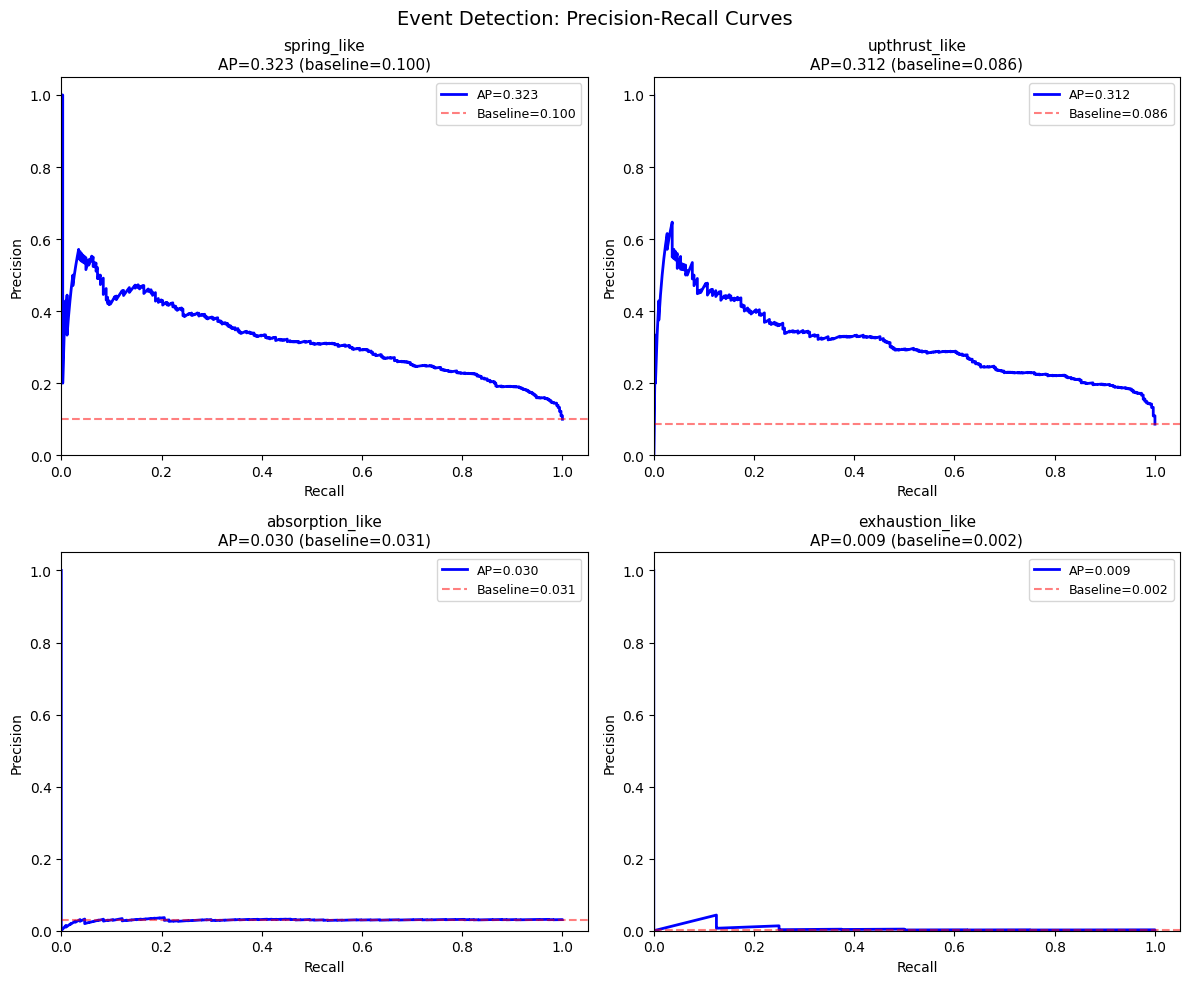

In [50]:
if ckpt is not None:
    # === Event PR-AUC ===
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()

    print('=== Event PR-AUC (Precision-Recall Area Under Curve) ===')
    for j, (name, ax) in enumerate(zip(EVENT_NAMES, axes)):
        y_true = (event_true_all[:, j] > 0).astype(int)
        y_score = event_probs[:, j]

        pos = y_true.sum()
        neg = len(y_true) - pos
        baseline = pos / len(y_true)

        if pos < 5:
            ax.text(0.5, 0.5, f'{name}\nToo few positives ({pos})',
                    transform=ax.transAxes, ha='center')
            print(f'  {name:18s}: SKIP (only {pos} positives)')
            continue

        ap = average_precision_score(y_true, y_score)
        precision, recall, thresholds = precision_recall_curve(y_true, y_score)

        ax.plot(recall, precision, lw=2, color='blue', label=f'AP={ap:.3f}')
        ax.axhline(baseline, color='red', ls='--', alpha=0.5, label=f'Baseline={baseline:.3f}')
        ax.set_xlabel('Recall')
        ax.set_ylabel('Precision')
        ax.set_title(f'{name}\nAP={ap:.3f} (baseline={baseline:.3f})', fontsize=11)
        ax.legend(fontsize=9)
        ax.set_xlim(0, 1.05)
        ax.set_ylim(0, 1.05)

        lift = ap / baseline if baseline > 0 else 0
        print(f'  {name:18s}: AP={ap:.4f}, baseline={baseline:.4f}, lift={lift:.1f}x, '
              f'pos={pos}, neg={neg}')

    plt.suptitle('Event Detection: Precision-Recall Curves', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print('Skipping -- no checkpoint')


## 10. Summary & Diagnosis

In [51]:
print('=' * 70)
print('LABEL AUDIT SUMMARY')
print('=' * 70)

# Regime
regime_counts = np.bincount(regime, minlength=3)
majority_pct = regime_counts.max() / len(regime) * 100
print(f'\n1. REGIME BALANCE')
print(f'   Majority class: {REGIME_NAMES[regime_counts.argmax()]} ({majority_pct:.1f}%)')
if majority_pct > 80:
    print(f'   WARNING: SEVERE imbalance -- model achieves {majority_pct:.0f}% by predicting majority')
elif majority_pct > 65:
    print('   WARNING: Moderate imbalance -- class weighting essential')
else:
    print('   OK: Reasonable balance')

# Events
print(f'\n2. EVENT SPARSITY')
for j, name in enumerate(EVENT_NAMES):
    pct = (events[:, j] > 0).sum() / len(events) * 100
    if pct < 0.5:
        status = 'VERY SPARSE -- may be unlearnable'
    elif pct < 2:
        status = 'Sparse -- needs strong pos_weight'
    elif pct > 15:
        status = 'Suspiciously frequent -- definition may be too loose'
    else:
        status = 'OK'
    print(f'   {name:18s}: {pct:.2f}% -- {status}')

# Run length
short_runs_pct = sum(1 for _, rl in runs if rl <= 2) / len(runs) * 100
print(f'\n3. REGIME STABILITY')
print(f'   Short segments (<=2 bars): {short_runs_pct:.1f}%')
if short_runs_pct > 20:
    print('   WARNING: Too many rapid flips -- labels are noisy')
else:
    print('   OK: Regime labels are reasonably stable')

# Overlap
both_su = ((events[:, 0] > 0) & (events[:, 1] > 0)).sum()
print(f'\n4. CONTRADICTORY LABELS')
print(f'   Spring + Upthrust overlap: {both_su} bars')
if both_su > 10:
    print('   WARNING: These are opposite events -- should not co-occur')
else:
    print('   OK: Clean')

print(f'\n5. KEY QUESTIONS FOR VISUAL INSPECTION')
print('   * Do springs actually show price breaking below support and reclaiming?')
print('   * Do upthrusts show rejection at resistance?')
print('   * Is absorption on high-vol doji-like bars?')
print('   * Are exhaustion bars genuine climax volume bars?')
print('   * Do regime labels track actual trend structure?')

print(f'\n6. RECOMMENDATIONS')
if majority_pct > 65:
    print('   -> Use class weights for regime CE loss')
for j, name in enumerate(EVENT_NAMES):
    pct = (events[:, j] > 0).sum() / len(events) * 100
    if pct < 1:
        neg = len(events) - (events[:, j] > 0).sum()
        pos = max((events[:, j] > 0).sum(), 1)
        print(f'   -> {name}: pos_weight={neg/pos:.0f}x (very sparse)')
    elif pct > 10:
        print(f'   -> {name}: definition may be too broad -- tighten thresholds')


LABEL AUDIT SUMMARY

1. REGIME BALANCE
   Majority class: balance (75.1%)

2. EVENT SPARSITY
   spring_like       : 8.47% -- OK
   upthrust_like     : 8.53% -- OK
   absorption_like   : 3.02% -- OK
   exhaustion_like   : 0.23% -- VERY SPARSE -- may be unlearnable

3. REGIME STABILITY
   Short segments (<=2 bars): 0.3%
   OK: Regime labels are reasonably stable

4. CONTRADICTORY LABELS
   Spring + Upthrust overlap: 8 bars
   OK: Clean

5. KEY QUESTIONS FOR VISUAL INSPECTION
   * Do springs actually show price breaking below support and reclaiming?
   * Do upthrusts show rejection at resistance?
   * Is absorption on high-vol doji-like bars?
   * Are exhaustion bars genuine climax volume bars?
   * Do regime labels track actual trend structure?

6. RECOMMENDATIONS
   -> Use class weights for regime CE loss
   -> exhaustion_like: pos_weight=432x (very sparse)
